# Illustris TNG for CGM oriented studies

Modern cosmological simulations have found success in reproducing many aspects that resemble the actual galaxy population that we observe in our universe, including things like the stellar/luminosity distributions, galaxy color bimodality, large-scale clustering, etc. 

Due to the large volumes these simulations use, the resolution element is often coarse with typical spatial resolution elements having sizes of the order of 1 kpc or larger. Therefore, by design, these simulations model all the small-scale phenomena in a coarse but physically motivated way, utilizing sub-grid models, especially within star formation and black hole collapse regions. These sub-grid models are key, as without them, simulations are not able to reproduce fundamental statistical distributions, like the stellar mass/luminosity functions. 

AGN and supernova feedback winds are also implemented as sub-grid models, as these are generated when certain conditions are met. For instance, all winds in TNG are initially oriented with no preferred direction, whose energy released per unit time is proportional to the instantaneous star formation rate. These particular implementations will directly impact the generated CGM in a given set of simulations (see [Wright et al. 2024](https://arxiv.org/pdf/2402.08408) for a recent comparison).

TNG is the successor of the Illustris cosmological simulations, including now magnetohydrodynamics, and a revised implementation of galactic winds. 
TNG includes three realizations, TNG300, TNG100 and TNG50, according to the simulated comoving volumes of $300^3$, $100^3$ and $50^3$ Mpc$^3$, respectively. TNG50 offers the smallest volume but also the best resolution. The following figure shows two column density maps around a TNG50 massive halo at $z=0.5$ ([Nelson et al. 2020](https://arxiv.org/pdf/2005.09654)), already showing a picture of the obtained CGM structure in these simulations.  

<img src="images/TNG50-1_z05_LRG_CGM.png" width="1000"/>
<div style="text-align: center;">
    <img src="images/TNG50-1_z05_LRG_CGM.png" width="1000"/>
</div>



The following tutorial aims to show the following: 

- Show how to access Illustris TNG data information and do simple plots about halo statistics. 
- Download a single halo and explore some properties of its data. 
- Do some basic visualization of the selected galaxy using YT.  

# Interacting with TNG API to retrieve halo information

In what follows we will access the TNG web API utilizing Python. With this API, we can download data and access some fundamental halo information. 

For more information I strongly suggest to explore TNG tutorials [here.](https://www.tng-project.org/data/docs/api/)


In [1]:
# The essentials
import numpy as np
import requests
import matplotlib.pyplot as plt 
import plotting_setup # comment this line if running local

In [2]:
# For our purposes we are going to use the web-api
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"6335ea41b5d1119dc38508e161c34f41"}     # this key is assigned to every usser. 
# This function will provide us with the result of every query we do. 
def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    return r

In [ ]:
# We ask for the snapshot of TNG 50 at z=1
# First we go to TNG50
sim_link = get(baseUrl)['simulations'][18]['url']
get(baseUrl)

In [107]:
# Now we ask for the snapshot at z = 1
snapshots_link = get(sim_link)['snapshots']
snapshots_link

'http://www.tng-project.org/api/TNG50-1/snapshots/'

In [ ]:
snapshot = get(snapshots_link)
snapshot

In [109]:
snapshot = get(snapshots_link)[50]['url']  # at index = 50 we get the snapshop at z = 1. 

In [7]:
subhalos = get(snapshot)['subhalos']

In [470]:
# Let's now do a query according to the ranges of mass
# Notice we need to convert the units to the ones TNG uses which in this case is  10^10 M0/h where h = 0.6774.   

min_mass = 10**(8)/1e10 * 0.6774
#max_mass = 10**(13.)/1e10 * 0.6774

search_query = "?mass_stars__gt=" + str(min_mass)
subhalos_query = get(subhalos +search_query, params={'limit': 100})

In [ ]:
subhalos_query['results']

Now, with each subhalo URL we can access the measured properties, like SFR, stellar mass, etc. 
Nevertheless, doing this is quite slow, as every time we will a query for each subhalo. Instead is better to directly work the group catalogs, one of the main outputs of the simulations. 

We will download the group catalogs for the $z=1$ snapshot. 

In [ ]:
%%bash 
mkdir group_catalogs
cd group_catalogs

wget -nd -nc -nv -e robots=off -l 1 -r -A hdf5 --content-disposition --header="API-Key: 6335ea41b5d1119dc38508e161c34f41" "http://www.tng-project.org/api/TNG50-1/files/groupcat-50/?format=api"

To load and explore the group catalogs the Illustris team has a package known as "illustris_python", you can simply install it with **pip**. 

In [4]:
import illustris_python as ill  # the magic package :) 

Before moving forward, we need to clarify what a "galaxy" is for TNG purposes, which is also key to understanding how the values we are going to explore were measured. 

For a given snapshot of the simulations, the different structures are identified. First, **halos** are identified. Halos are defined as the outcome of a Friend of Friends algorithm, which groups together all particles that are close within some linking length $b$. This approximately guarantees that a halo is enclosed within an iso-density surface that goes like $\rho \propto 1/b^3$. This algorithm is run over the Dark Matter particles only, and all the other particles are then associated with their closest DM particle.

A halo can be a big structure including several things that we may call "galaxies", so a halo typically has a massive galaxy and its associated environment, with less massive galaxies being considered satellites. To identify every substructure within halos the **subfind** algorithm is executed (see [Springel et al. 2001](https://arxiv.org/pdf/astro-ph/0012055) for a detailed description). 

The main objective of the subfind algorithm is to detect small gravitationally bounded structures within a larger parent group (a halo found with FOF technique).  To do this, Subfind looks for overdensities relative to the underlying matter distribution, i.e., local overdensities, and finally, for each candidate, only the self-bounded structures are retained. This defines a **subhalo**, which is a structure that, by construction, is bounded, as we may expect for a galaxy. 

Using this language, a halo is a collection of subhalos, with subhalos being treated as individual galaxies. We will now look into the catalog of subhalos and explore their statistics! 


In [108]:
basePath = 'D:/TNG-and-TRIDENT-for-CGM-oriented-science'

# we are going to only explore the SFR and stellar mass within the half mass radius, which should be better when comparing with observations.
# We are also going to extract other properties that are going to be useful later, like the position, bulk velocity and total SFR.  
fields = ['SubhaloSFRinHalfRad', 'SubhaloMassInHalfRadType', 'SubhaloSFR', 'SubhaloPos', 
          'SubhaloVel' , 'SubhaloGrNr' , 'SubhaloMass', 'SubhaloCM'] 

subhalos_catalog = ill.groupcat.loadSubhalos(basePath, 50,fields=fields)

We are going to reproduce two very well known plots from galaxies statistics, stellar mass distribution and the SFR as a function of stellar mass. 

### The Galaxy stellar mass function (GSMF) 

In [6]:
# We start by defining the single and double Schecter functions to compare with the observed distribution :) 

def schecter_function(phi_star, M_star,alpha, M):

    A = phi_star *np.log(10)
    power_law = (10**(M-M_star)) ** (1+alpha)
    exponential = np.exp(-10**(M-M_star))

    return A * power_law * exponential

def double_schecter_function(phi_star1, phi_star2, M_star, alpha1, alpha2, M):

    A = np.log(10) * np.exp(-10**(M-M_star)) * (10**(M - M_star))

    power_law1 = phi_star1 * (10**(M-M_star)) ** (alpha1)
    power_law2 = phi_star2 * (10**(M-M_star)) ** (alpha2)

    return A * (power_law1 + power_law2)

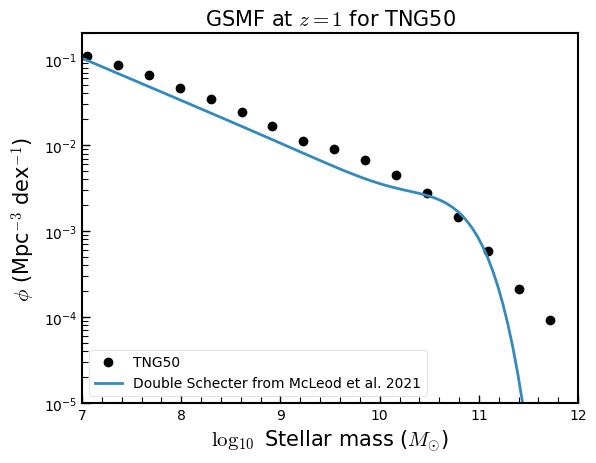

In [7]:
# first we compute the log of the stellar mass (PartType04 en este caso!)
stellar_mass = subhalos_catalog['SubhaloMassInHalfRadType'][:, 4]  * (1e10 / 0.6774) # don't forget about the unit conversion!

# we avoid subhalos with 0 stellar mass
non_zero = np.where(stellar_mass > 0)
log_mass = np.log10(stellar_mass[non_zero])

counts, edges = np.histogram(log_mass, bins=25)
bin_width = edges[1] - edges[0]

# We know that the total comoving volume is 51.7**3 Mpc
norm_factor = (51.7)**3 * bin_width

plt.plot(0.5 * (edges[:-1] + edges[1:]), counts / norm_factor, 'o', color='black', label='TNG50')
plt.plot(np.linspace(7, 12,100), double_schecter_function(10**(-2.67), 10**(-3.07), 10.51, 0.08, -1.49, np.linspace(7, 12,100))
        , label='Double Schecter from McLeod et al. 2021')
plt.ylim(1e-5, 2e-1)

plt.yscale('log')
plt.xlim(7, 12.)

plt.ylabel(r'$\phi$ (Mpc$^{-3}$ dex$^{-1}$)', fontsize=15)
plt.xlabel(r'$\log_{10}$ Stellar mass ($M_{\odot}$)', fontsize=15)
plt.legend(loc=3)
plt.title('GSMF at $z=1$ for TNG50', fontsize=15)
plt.show()

You can notice that the galaxy population at $z=1$ in TNG50 is already different from the observed galaxy population, with a systematic overprediction of galaxies at almost all stellar mass ranges (though less dramatic in the intermediate and low mass regime). This seems to be a known issue, not exclusive to TNG (see [McLeod et al. 2021](https://arxiv.org/pdf/2009.03176) Fig. 9 for example). 

Anyways, consider that example as a proof of concept, and also note that the volume in TNG50 is small, therefore larger volume simulations (like TNG300) are much better to really asses if the GSMF is well reproduced or not (look at Fig. 14 in [Pillepich et al. 2018](https://arxiv.org/pdf/1707.03406)). 


### Star formation rate as a function of stellar mass

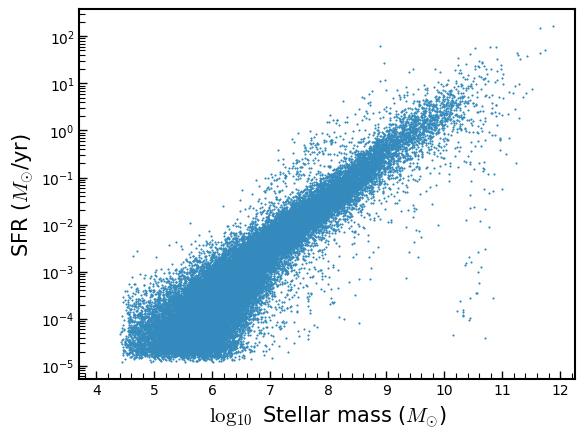

In [8]:
sfr_all = subhalos_catalog['SubhaloSFRinHalfRad'] 

plt.scatter(log_mass, sfr_all[non_zero], s=1) 
plt.xlabel(r'$\log_{10}$ Stellar mass ($M_{\odot}$)', fontsize=15)
plt.ylabel(r'SFR ($M_{\odot}$/yr)', fontsize=15)
plt.yscale('log')

Notice that, because of the limit in mass resolution of TNG50, there is also a minimum SFR that can exist in the gas particles. 

Therefore, the horizontal sharp cut at $SFR \sim 10^{-5} M_{\odot}/yr$ is artificial!  

Anything beyond, should have zero SFR. Let's have a look at how many galaxies have 0 SFR, which should be considered when studying quenched galaxies for instance. 

In [9]:
# Are there any galaxies with SFR 0? 

print('Number of galaxies with 0 SFR: {}'.format(np.sum(sfr_all == 0.)))

Number of galaxies with 0 SFR: 6742351


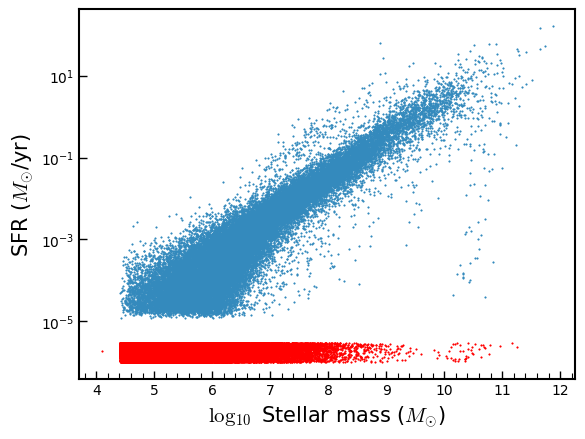

In [10]:
# To add them, we are going to add them with an SFR 10^-6 with some random uniform noise.

zero_sfr = sfr_all[non_zero] == 0.

plt.scatter(log_mass, sfr_all[non_zero], s=1) 
plt.scatter(log_mass[zero_sfr], sfr_all[non_zero][zero_sfr] + np.random.uniform(low=1e-6, high=3e-6, size=zero_sfr.sum()), s=1, color='red') 

plt.xlabel(r'$\log_{10}$ Stellar mass ($M_{\odot}$)', fontsize=15)
plt.ylabel(r'SFR ($M_{\odot}$/yr)', fontsize=15)
plt.yscale('log')

# Exploring a single galaxy

Now, we know how to explore the overall statistics of galaxies within TNG50.
In what follows, we will explore a single galaxy, doing a couple of CGM-motivated experiments. 

We start by downloading an arbitrary galaxy, the subhalo with ID = 110863.  We will use the API to extract some of its relevant values.

There is three datasets we can download from TNG: Subhalos cutouts (i.e. only the particles gravitationally bounded to our selected

In [12]:
print(f'We are going to download the cutout asociated to the full halo where our galaxy resides (Halo id = {halo_id})')

We are going to download the cutout asociated to the full halo where our galaxy resides (Halo id = 10)


When downloading a dataset of a given galaxy, we have three options. Download only the dataset associated with the subhalo, download the parent halo, or download the entire snapshot. 

For CGM purposes, using halos is a good choice, because subhalos cutouts can end abruptly, producing artificial empty regions. Also, whenever exploring the CGM of a massive galaxy, we want to consider the contribution that satellites may produce within the CGM-defined region around our selected galaxy.

Now we proceed to download the parent halo of our selected galaxy.


In [13]:
def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string

    return r

In [128]:
id_subhalo = 110863
url = get(snapshot)['subhalos'] + f'{id_subhalo}/'

subhalo_query = get(url)

parent_halo_url = subhalo_query['related']['parent_halo']

In [134]:
# Now we download, only the gas and stars

# This may take a while
cutout_request = {'gas': 'all', 'stars':'all'}  
get(subhalo_query['cutouts']['parent_halo'], params=cutout_request)

'cutout_10.hdf5'

## Exploring the multiphase of the CGM 

Now that we have our subhalo downloaded, we will explore the gaseous properties of it. 

We will do three activities:

- Using TRIDENT, add the ions component of MgII, CIV and OVI, and explore their mass-weighted temperature distribution. 

- After defining a CGM region, explore the distribution of particles that are either inflowing or outflowing. Explore their differences in metallicity, and compute a mass loading factor for our galaxy. 

- Produce column density maps and compute the radial covering fraction of many species. 

To deal with the dataset we downloaded, we are going to use the package **YT**, which is going to load the dataset, deal with the units, produce projected maps, etc. Give it a look [here!](https://yt-project.org)

To install TRIDENT, please refer to the [documentation](https://trident.readthedocs.io/en/latest/). 

In [73]:
# You probably need to install both YT and TRIDENT. 
import yt
import yt.units
import trident 

from astropy.cosmology import FlatLambdaCDM
from astropy import units as u


In [17]:
trident.__version__, yt.__version__, trident.__path__

('1.3', '4.0.5', ['C:\\ProgramData\\Anaconda3\\lib\\site-packages\\trident'])

In February of 2025, TRIDENT has a major update (version 1.4.2), I would reccomend to install that version.

Do note that, when first running TRIDENT, you will be asked to install a ionization table. For consistency purposes with TNG, I selected the table that uses Faucher-Giguere 2009 UV Background with Self-Shielding. 

Now that we have everything in place, we will start by defining the CGM region. To this end, we need to compute the virial radius, which for a given total mass $M$ can be defined with the following equation:

$$\Delta_c(z) \rho_c(z) \cdot \left(\frac{4\pi}{3} R_{vir}^3\right) = M  $$

Therefore, the virial radius is the distance for which a given total mass has a density that is $\Delta_c$ times the critical density of the universe at a given redshift. Some works typically assume $\Delta_c = 200$ (at $z=0$). More detailed analysis of the collapse of dark matter halos reveals that $\Delta_c$ depends on the cosmology. You can assume values from [Bryan et al. 1998](https://arxiv.org/pdf/astro-ph/9710107). Do note that the virial radius needs to include the total mass of your halo (or at least the dominant component, which is typically the dark matter). 

In [21]:
def fit_delta_crit(x):
    # Extracted from Bryan 1998 (fit with Omega_R = 0)
    return 18*np.pi**2 + 82*x - 39*(x**2)

def virial_radius(M, z):
    # Mass has to be given in units of solar masses
    cosmo = FlatLambdaCDM(H0 = 67.74, Om0=0.3089, Ob0=0.0486)
    density = fit_delta_crit(cosmo.Om(z) - 1) * cosmo.critical_density(z)
    
    # density = 200 * cosmo.critical_density(z)  use this to use typical TNG definition of the virial radius

    density = density.to(u.M_sun/u.kpc**3)
    r_cube = (3/(4*np.pi*density)) * (M*u.M_sun)

    return r_cube**(1/3)

In [95]:
# Now we load our dataset with yt!
ds = yt.load('cutout_10.hdf5') 

yt : [INFO     ] 2025-06-22 13:14:36,737 Calculating time from 5.007e-01 to be 1.855e+17 seconds
yt : [INFO     ] 2025-06-22 13:14:36,820 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-22 13:14:36,823 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-22 13:14:36,826 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-06-22 13:14:36,828 Parameters: domain_right_edge         = [35000. 35000. 35000.]
yt : [INFO     ] 2025-06-22 13:14:36,829 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-22 13:14:36,830 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-22 13:14:36,831 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-22 13:14:36,831 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-22 13:14:36,832 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-22 13:14:36,833 Parameters: hubble_constant

In [ ]:
# You can see all its stored values with

ds.derived_field_list

In [109]:
# We will also add the units accordingly 

center = subhalos_catalog['SubhaloCM'][110863] # we will left this with code units         
velocity_gal = subhalos_catalog['SubhaloVel'][110863] * (yt.units.km / yt.units.s) 
total_SFR = subhalos_catalog['SubhaloSFR'][110863] * (yt.units.Msun / yt.units.yr) 
total_mass = subhalos_catalog['SubhaloMass'][110863] * (1e10/0.6774) * yt.units.Msun 

# Parent halo id
halo_id = subhalos_catalog['SubhaloGrNr'][110863]

In [42]:
# Yt allows us to deal with the units quite easily. 

ds.length_unit , ds.velocity_unit , ds.mass_unit, ds.current_redshift

(unyt_quantity(1.00000014, 'kpccm/h'),
 unyt_quantity(100000., 'sqrt(a)*cm/s'),
 unyt_quantity(1.989e+43, 'g/h'),
 0.9972942257819404)

You can do the conversions manually, or let YT take care of everything. Note that for YT, the unit *kpc* means proper kiloparsecs, while *kpccm* means comoving kiloparsecs.

In [51]:
print('YT conversion: {:.6f}'.format(ds.length_unit.to('kpc')))
print('Manual conversion: {:.6f}'.format(ds.length_unit.value * (1/0.6774)  / (1 + ds.current_redshift) * kpc))

YT conversion: 0.739116 kpc
Manual conversion: 0.739116 kpc


In [78]:
R_vir = virial_radius(total_mass, 1)
R_vir

<Quantity 173.26358523 kpc>

## Mg II, C IV, and O VI temperature distribution

In [145]:
# We add the ion fields to our dataset :) 
trident.add_ion_fields(ds, ions = ['Mg II', 'C IV', 'O VI'])

yt : [WARNING  ] 2025-06-22 15:52:03,260 Field ('gas', 'Mg_p1_ion_fraction') already exists. Not clobbering.
yt : [WARNING  ] 2025-06-22 15:52:03,260 Field ('gas', 'Mg_p1_number_density') already exists. Not clobbering.
yt : [WARNING  ] 2025-06-22 15:52:03,262 Field ('gas', 'Mg_p1_density') already exists. Not clobbering.
yt : [WARNING  ] 2025-06-22 15:52:03,263 Field ('gas', 'Mg_p1_mass') already exists. Not clobbering.
yt : [WARNING  ] 2025-06-22 15:52:03,264 Field ('gas', 'C_p3_ion_fraction') already exists. Not clobbering.
yt : [WARNING  ] 2025-06-22 15:52:03,265 Field ('gas', 'C_p3_number_density') already exists. Not clobbering.
yt : [WARNING  ] 2025-06-22 15:52:03,265 Field ('gas', 'C_p3_density') already exists. Not clobbering.
yt : [WARNING  ] 2025-06-22 15:52:03,267 Field ('gas', 'C_p3_mass') already exists. Not clobbering.
yt : [WARNING  ] 2025-06-22 15:52:03,268 Field ('gas', 'O_p5_ion_fraction') already exists. Not clobbering.
yt : [WARNING  ] 2025-06-22 15:52:03,268 Field

In [97]:
# we are going to select all data within a sphere defined by our virial radius
masked_data = ds.sphere(center=center * ds.length_unit, radius=(R_vir.value, 'kpc'))

In [98]:
temperature = masked_data[('PartType0', 'temperature')] # already in kelvins

In [99]:
# Computing a mean temperature weighted by mass

mean_mgii = np.sum(masked_data[('gas', 'Mg_p1_mass')] * temperature)/np.sum(masked_data[('gas', 'Mg_p1_mass')])
mean_civ = np.sum(masked_data[('gas', 'C_p3_mass')] * temperature)/np.sum(masked_data[('gas', 'C_p3_mass')])
mean_ovi = np.sum(masked_data[('gas', 'O_p5_mass')] * temperature)/np.sum(masked_data[('gas', 'O_p5_mass')])

In [100]:
print('Mean temperature for Mg II: {:.2e}'.format(mean_mgii))
print('Mean temperature for C IV: {:.2e}'.format(mean_civ))
print('Mean temperature for O VI: {:.2e}'.format(mean_ovi))

Mean temperature for Mg II: 1.37e+04 K
Mean temperature for C IV: 7.73e+04 K
Mean temperature for O VI: 4.59e+05 K


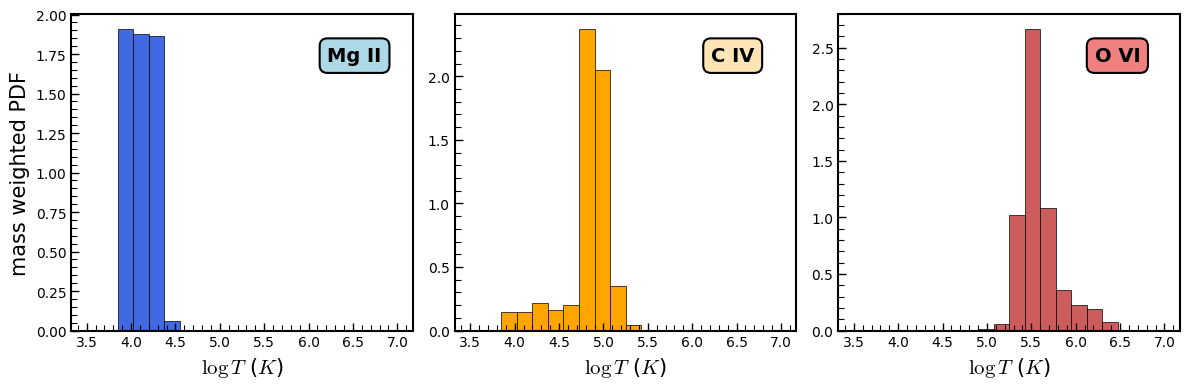

In [101]:
bins = np.linspace(3.5, 7, 21)
plt.figure(figsize=(12, 4))

# Subplot 1: Mg II
plt.subplot(131)
plt.hist(np.log10(temperature.value), weights=masked_data[('gas', 'Mg_p1_mass')].value,
            density=True, bins=bins, edgecolor='black', facecolor='royalblue')
plt.xlabel(r'$\log T$ ($K$)', fontsize=15)
plt.ylabel('mass weighted PDF', fontsize=15)
plt.text(0.75, 0.85, 'Mg II', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='lightblue', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

# Subplot 2: C IV
plt.subplot(132)
plt.hist(np.log10(temperature.value), weights=masked_data[('gas', 'C_p3_mass')].value,
            density=True, bins=bins, edgecolor='black', facecolor='orange')
plt.xlabel(r'$\log T$ ($K$)', fontsize=15)
plt.text(0.75, 0.85, 'C IV', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='moccasin', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

# Subplot 3: O VI
plt.subplot(133)
plt.hist(np.log10(temperature.value), weights=masked_data[('gas', 'O_p5_mass')].value,
            density=True, bins=bins, edgecolor='black', facecolor='indianred')
plt.xlabel(r'$\log T$ ($K$)', fontsize=15)
plt.text(0.75, 0.85, 'O VI', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='lightcoral', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

plt.tight_layout()
plt.show()

As expected, higher ionization energy species trace higher temperatures :) 

Notice that this result is affected by two things mainly, how TNG tracks the content of metals, and how TRIDENT computes the ions of each metal. 

## Inflowing and outflowing gas

Now, let's turn into something that is not computed in the data already. 

The objective of this sections is to inspect inflowing and outflowing gas, and compute the mass loading factor $\eta = \dot{M}/SFR$ for this galaxy. 

To this end, we will compute the radial velocity of the gas relative to bulk velocity of the galaxy. 

So, if $\vec{r}$ is the gas position vector relative to the center of the subhalo, and $\vec{v}$ the rel. velocity, then:

$$\cos (\theta) = \frac{\vec{r} \cdot \vec{v}}{|\vec{r}| |\vec{v}|} $$

Then, we define outflowing gas as every particle with $\cos (\theta) > 0$, and inflowing as $\cos (\theta) < 0$. 

In [110]:
coordinates_sphere = masked_data[('PartType0', 'Coordinates')]
rel_coordinates = coordinates_sphere - center * ds.length_unit
radius = np.sqrt(np.sum(rel_coordinates**2, axis=1))

In [111]:
rel_velocity = masked_data[('PartType0', 'Velocities')].to('km/s') - velocity_gal

dot_prod = np.sum(rel_velocity * rel_coordinates, axis=1)
norm_vel = np.sqrt(np.sum(rel_velocity**2, axis=1))
norm_position = np.sqrt(np.sum(rel_coordinates**2, axis=1))

cos_angle = dot_prod / (norm_vel * norm_position) 

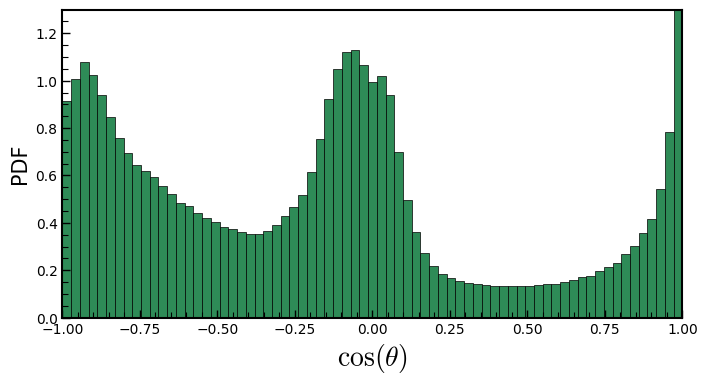

In [112]:
plt.figure(figsize=(8,4))
plt.hist(cos_angle, bins=71, edgecolor='black', density=True, facecolor='seagreen')
plt.xlabel(r'$\cos(\theta)$', fontsize=20)
plt.ylabel('PDF', fontsize=15)
plt.ylim(0, 1.3)
plt.xlim(-1,1)
plt.show()

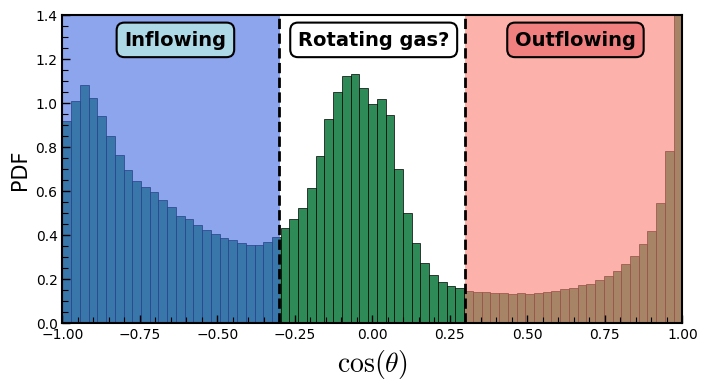

In [118]:
plt.figure(figsize=(8,4))
plt.hist(cos_angle, bins=71, edgecolor='black', density=True, facecolor='seagreen')
plt.xlabel(r'$\cos(\theta)$', fontsize=20)
plt.ylabel('PDF', fontsize=15)

plt.vlines([-0.3, 0.3], [0,0], [1.4,1.4], linestyles='--', color='black')
plt.fill_between([-1, -0.3], 0, 1.4, color='royalblue', alpha=0.6)
plt.fill_between([0.3, 1], 0, 1.4, color='salmon', alpha=0.6)

plt.text(0.1, 0.90, 'Inflowing', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='lightblue', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)


plt.text(0.73, 0.90, 'Outflowing', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='lightcoral', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

plt.text(0.38, 0.90, 'Rotating gas?', transform=plt.gca().transAxes,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='white', edgecolor='black', alpha=1, linewidth=1.5), weight='bold', fontsize=14)

plt.xlim(-1,1)
plt.ylim(0, 1.4)
plt.show()

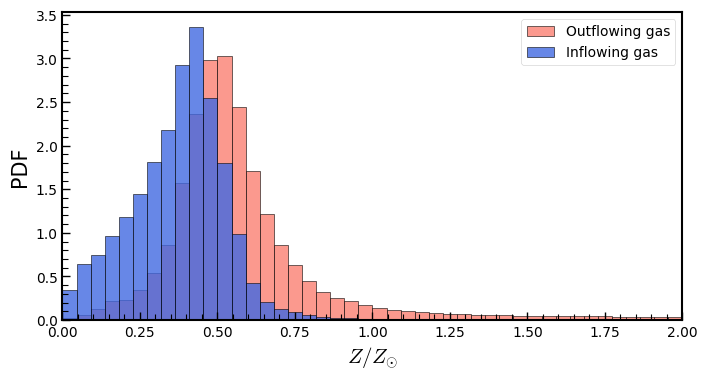

In [124]:
outflowing_gas = cos_angle > 0.
inflowing_gas = cos_angle < -0.

radius_mask = radius.to('kpc') > 0.1 * R_vir.value * kpc 

bins = np.linspace(0,2, 45)

plt.figure(figsize=(8,4))

# We divide by 0.0127 to normalize to solar
plt.hist(masked_data[('PartType0', 'GFM_Metallicity')][outflowing_gas * radius_mask]/0.0127, bins = bins, edgecolor='black', 
            density=True, alpha=0.8, facecolor='salmon', label='Outflowing gas')
plt.xlim(0,2)

plt.hist(masked_data[('PartType0', 'GFM_Metallicity')][inflowing_gas * radius_mask]/0.0127, bins=bins, edgecolor='black', 
            density=True, alpha=0.8, facecolor='Royalblue', label='Inflowing gas')
plt.xlim(0,2)

plt.ylabel('PDF', fontsize=15)
plt.xlabel(r'$Z/Z_{\odot}$', fontsize=15)
plt.legend()
plt.show()

Finally, we are going to compute the mass loading factor of this galaxy using only the **CGM gas**. 

To this end, we are going to compute the instantaneous radial mass flux as

$$\dot{M} = \frac{1}{\Delta r} \sum_{i} \left( \frac{\vec{v}_i \cdot \vec{r}_i}{|\vec{r_i}|} m_i\right) $$

where the summation index goes for all the gas cells within a spherical shell of thickness of $\Delta r$. 

Notice again, that both the velocity and coordinates are relative. 

Finally, the mass loading factor is simply $\eta = \dot{M}/SFR$. 

In [125]:
inner_cgm_radius = 0.1 * R_vir.value * kpc 
outer_cgm_radius = 1.0 * R_vir.value * kpc
delta_r = outer_cgm_radius - inner_cgm_radius

mask_radius = (radius.to('kpc') > inner_cgm_radius) * (radius.to('kpc') < outer_cgm_radius)

mask_outflow = outflowing_gas * mask_radius
mask_inflow = inflowing_gas * mask_radius

In [135]:
# We compute some values before hand :) 

vel_pos_dot_prod_out = np.sum(rel_velocity[mask_outflow] * rel_coordinates[mask_outflow], axis=1)
norm_position_out = np.sqrt(np.sum(rel_coordinates[mask_outflow]**2, axis=1))
masses_out = masked_data[('PartType0', 'Masses')].to('Msun')[mask_outflow]

vel_pos_dot_prod_in = np.sum(rel_velocity[mask_inflow] * rel_coordinates[mask_inflow], axis=1)
norm_position_in = np.sqrt(np.sum(rel_coordinates[mask_inflow]**2, axis=1))
masses_in = masked_data[('PartType0', 'Masses')][mask_inflow]

# now M_dot 

M_dot_out = (1/delta_r) * np.sum(vel_pos_dot_prod_out * masses_out/ norm_position_out )
M_dot_in = (1/delta_r) * np.sum(vel_pos_dot_prod_in * masses_in/ norm_position_in )

print('Eta (for outflowing gas): {:.2f}'.format((M_dot_out/total_SFR).value))

print('Eta (for inflowing gas): {:.2f}'.format((-M_dot_in/total_SFR).value))

Eta (for outflowing gas): 1.57
Eta (for inflowing gas): 2.04


In [445]:
radius_stars = np.sqrt(np.sum((masked_data[('PartType4', 'Coordinates')] - center * ds.length_unit)**2, axis=1))

mask_stars_radius = radius_stars.to('kpc') < 10 * kpc  
velocities_stars = np.sqrt(np.sum((masked_data[('PartType4', 'Velocities')].to('km/s') - velocity_halo)**2, axis=1))

plt.plot(radius_stars.to('kpc'), velocities_stars, 'o', markersize=1.5, alpha=0.1)
plt.show()

## Column density visualizations

YT allow us to directly compute projection maps for a given direction. As an example, we can use this to project the density of our ions to produce column density maps.

In [ ]:
fields = [('gas', 'Mg_p1_number_density'), ('gas', 'C_p3_number_density'), ('gas', 'O_p5_number_density'), ('PartType0', 'H_p0_number_density')]
projections = yt.ProjectionPlot(ds, 'z', fields, center=center * ds.length_unit, width=(2 * R_vir.value,'kpc'))

yt : [INFO     ] 2025-06-22 19:30:55,748 xlim = 26604.718740 27073.558604
yt : [INFO     ] 2025-06-22 19:30:55,748 ylim = 2977.065908 3445.905772
yt : [INFO     ] 2025-06-22 19:30:55,749 xlim = 26604.715127 27073.554927
yt : [INFO     ] 2025-06-22 19:30:55,750 ylim = 2977.065504 3445.905304
yt : [INFO     ] 2025-06-22 19:30:55,754 Making a fixed resolution buffer of (('gas', 'C_p3_number_density')) 800 by 800
yt : [WARNING  ] 2025-06-22 19:31:09,721 Plotting ('gas', 'C_p3_number_density'): Both positive and negative values. Min = 0.0 cm**(-2), Max = 1.614550916220098e+20 cm**(-2).
yt : [WARNING  ] 2025-06-22 19:31:09,722 Switching to symlog colorbar scaling.
yt : [INFO     ] 2025-06-22 19:31:09,911 Making a fixed resolution buffer of (('gas', 'O_p5_number_density')) 800 by 800
yt : [WARNING  ] 2025-06-22 19:31:23,645 Plotting ('gas', 'O_p5_number_density'): Both positive and negative values. Min = 0.0 cm**(-2), Max = 2.7799360996050024e+16 cm**(-2).
yt : [WARNING  ] 2025-06-22 19:31:23

In [ ]:
# We can also extract the arrays that produced those plots to work with them.
arr_projections = []
for i, field in enumerate(fields):
    axes = projections.plots[field].axes
    img = axes.get_children()[0]
    arr_projections.append(img.get_array())

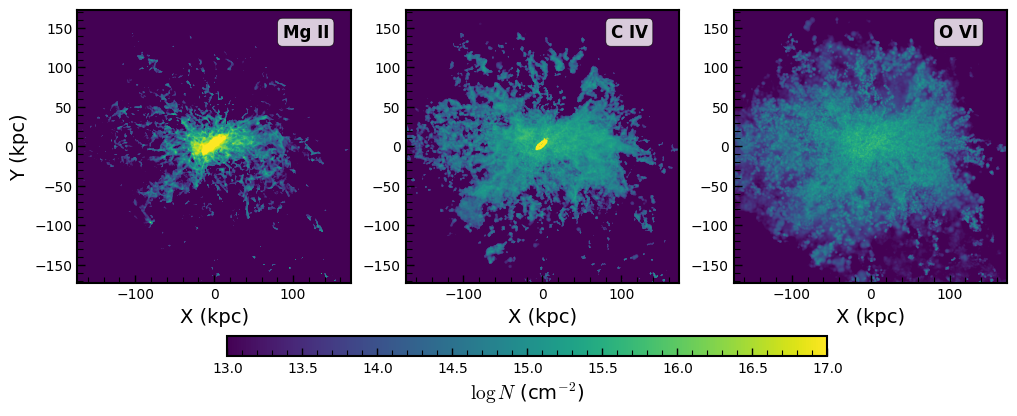

In [272]:
# And now we deal with them as arrays:) 

plt.figure(figsize=(12,4))

for array in arr_projections:
    # set 0 values to a very low column density, just for visualization purposes
    array[np.where(array == 0.)] += 1e-20

# Create the subplots
ax1 = plt.subplot(131)
im1 = ax1.imshow(np.log10(arr_projections[0]), origin='lower', extent=[-R_vir.value, R_vir.value, -R_vir.value, R_vir.value])
ax1.set_xlabel('X (kpc)', fontsize=14)
ax1.set_ylabel('Y (kpc)', fontsize=14)
im1.set_clim(13, 17)

# Add text with a rounded box in the top-left corner
ax1.text(0.75, 0.95, 'Mg II', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

ax2 = plt.subplot(132)
im2 = ax2.imshow(np.log10(arr_projections[1]), origin='lower', extent=[-R_vir.value, R_vir.value, -R_vir.value, R_vir.value])
ax2.set_xlabel('X (kpc)', fontsize=14)
im2.set_clim(13, 17)

ax2.text(0.75, 0.95, 'C IV', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

ax3 = plt.subplot(133)
im3 = ax3.imshow(np.log10(arr_projections[2]), origin='lower', extent=[-R_vir.value, R_vir.value, -R_vir.value, R_vir.value])
ax3.set_xlabel('X (kpc)', fontsize=14)
im3.set_clim(13, 17)

ax3.text(0.75, 0.95, 'O VI', transform=ax3.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

# Add horizontal colorbar below the subplots
cbar_ax = plt.gcf().add_axes([0.25, -0.03, 0.5, 0.05])  # [left, bottom, width, height]
cbar = plt.colorbar(im3, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'$\log N$ (cm$^{-2}$)', fontsize=14)

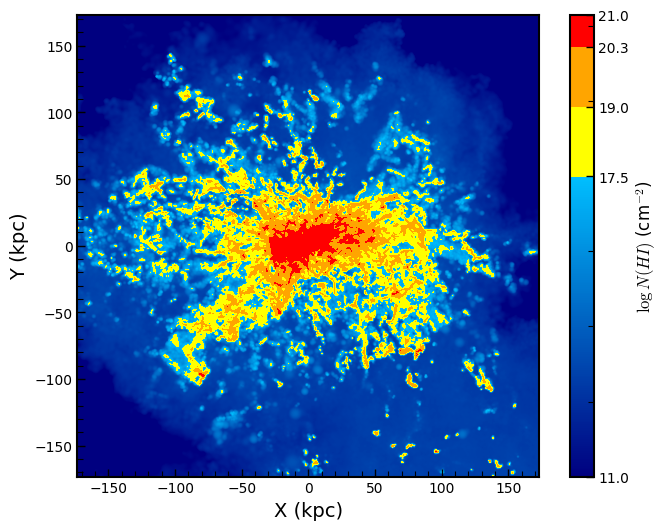

In [303]:
# And HI :) 
import matplotlib.colors as mcolors

# This "fancy" color map is only to color different known regimes like Ly alpha forest, lyman limit, sub-dlas and DLAs
# Create custom colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_cmap',
    [
        (0.0, 'navy'),         # 11
        (0.65, 'deepskyblue'),  # 17.5 (end of gradient)
        (0.65, 'yellow'),       # flat yellow starts
        (0.8, 'yellow'),      # 19
        (0.8, 'orange'),      # flat orange starts
        (0.93, 'orange'),      # 20.3
        (0.93, 'red'),         # flat red
        (1.0, 'red')           # >20.3
    ]
)

# 2. Normalize your values to [11, 21] (21 to cover any outliers)
norm = mcolors.Normalize(vmin=11, vmax=21)

# Plot
plt.figure(figsize=(8, 6))
img = plt.imshow(np.log10(arr_projections[3]), origin='lower', extent=[-R_vir.value, R_vir.value, -R_vir.value, R_vir.value],
                 cmap=cmap, norm=norm)
plt.xlabel('X (kpc)', fontsize=14)
plt.ylabel('Y (kpc)', fontsize=14)
plt.colorbar(img, label=r'$\log N(HI)$ (cm$^{-2}$)', ticks=bounds)

What if we want to see this galaxy edge-on, face-on or have any control over the inclination? In those cases we can use the off-axis projection from yt. We will use the angular momentum of the stars within $0.1 R_{vir}$ to define our inclination.

<div style="text-align: center;">
    <img src="images/geometry.png" width="600" />
</div>


Where $\vec{L}$ is the angular momentum, $\vec{L_N} = \vec{L} \times \hat{z}$. 
Our projection is going to be done parallel to the projection vector $\vec{P} = \cos(\alpha)\vec{L_N}  + \sin(\alpha) \vec{L}$. For the purposes of the plot, we need to define a north vector, that is going to point upwards in the plot. Therefore $\vec{N} = \cos(\alpha)\vec{L} - \sin(\alpha) \vec{L_{N}}$.

In [224]:
import coordinates as coords

In [243]:
# we compute the angular momentum
sp = ds.sphere(center, (0.1 * R_vir.value, 'kpc'))

P_edge_on, N_edge_on, W = coords.create_PNW_base(ds, 0, center,0.1 * R_vir.value)        # edge on
P_face_on, N_face_on, W = coords.create_PNW_base(ds, np.pi/2, center,0.1 * R_vir.value)  # face on
P_mid, N_mid, W = coords.create_PNW_base(ds, np.pi/4, center,0.1 * R_vir.value)  # middle inclination

In [260]:
projection_edge_on = yt.OffAxisProjectionPlot(ds, P_edge_on, fields= ('gas', 'Mg_p1_number_density'), center=sp.center,
                                            width=(R_vir.value, 'kpc'), north_vector=N_edge_on) 

projection_face_on = yt.OffAxisProjectionPlot(ds, P_face_on, fields= ('gas', 'Mg_p1_number_density'), center=sp.center,
                                            width=(R_vir.value, 'kpc'), north_vector=N_face_on) 

projection_mid = yt.OffAxisProjectionPlot(ds, P_mid, fields= ('gas', 'Mg_p1_number_density'), center=sp.center,
                                            width=(R_vir.value, 'kpc'), north_vector=N_mid) 

yt : [INFO     ] 2025-06-22 17:28:19,670 xlim = -117.209950 117.209950
yt : [INFO     ] 2025-06-22 17:28:19,671 ylim = -117.209950 117.209950
yt : [INFO     ] 2025-06-22 17:28:19,672 zlim = -17500.000000 17500.000000
yt : [INFO     ] 2025-06-22 17:28:19,673 Making a fixed resolution buffer of (('gas', 'Mg_p1_number_density')) 800 by 800
yt : [WARNING  ] 2025-06-22 17:28:43,516 Plotting ('gas', 'Mg_p1_number_density'): Both positive and negative values. Min = 0.0 cm**(-2), Max = 4.820496108664217e+17 cm**(-2).
yt : [WARNING  ] 2025-06-22 17:28:43,518 Switching to symlog colorbar scaling.
yt : [INFO     ] 2025-06-22 17:28:43,762 xlim = -117.209950 117.209950
yt : [INFO     ] 2025-06-22 17:28:43,763 ylim = -117.209950 117.209950
yt : [INFO     ] 2025-06-22 17:28:43,764 zlim = -17500.000000 17500.000000
yt : [INFO     ] 2025-06-22 17:28:43,764 Making a fixed resolution buffer of (('gas', 'Mg_p1_number_density')) 800 by 800
yt : [WARNING  ] 2025-06-22 17:29:09,391 Plotting ('gas', 'Mg_p1_nu

In [261]:
# Again, we extract the arrays that produced those plots to work with them.
arr_projections_geometry = []
for i, proj in enumerate([projection_edge_on, projection_face_on, projection_mid]):
    axes = proj.plots[('gas', 'Mg_p1_number_density')].axes
    img = axes.get_children()[0]
    arr_projections_geometry.append(img.get_array())

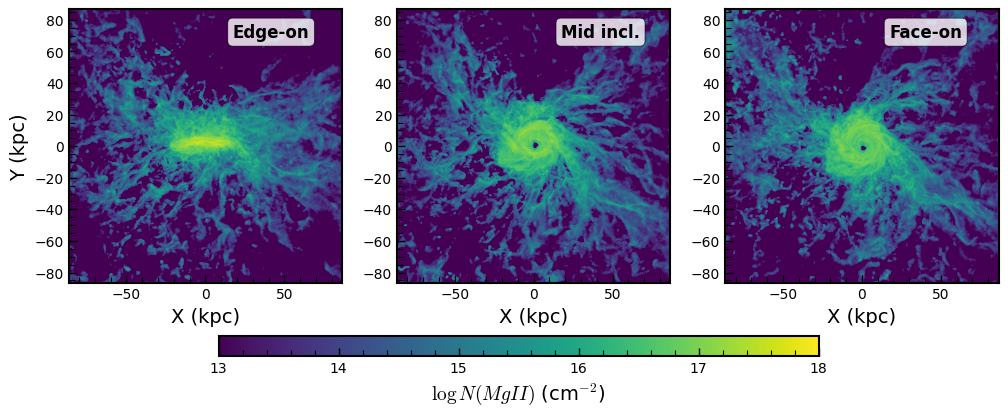

In [315]:
# And now we deal with them as arrays:) 

plt.figure(figsize=(12,4))

for array in arr_projections_geometry:
    # set 0 values to a very low column density, just for visualization purposes
    array[np.where(array == 0.)] += 1e-20

# Create the subplots
ax1 = plt.subplot(131)
im1 = ax1.imshow(np.log10(arr_projections_geometry[0]), origin='lower', extent=[-R_vir.value/2, R_vir.value/2, -R_vir.value/2, R_vir.value/2])
ax1.set_xlabel('X (kpc)', fontsize=14)
ax1.set_ylabel('Y (kpc)', fontsize=14)
im1.set_clim(13, 18)

# Add text with a rounded box in the top-left corner
ax1.text(0.6, 0.95, 'Edge-on', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

ax2 = plt.subplot(132)
im2 = ax2.imshow(np.log10(arr_projections_geometry[2]), origin='lower', extent=[-R_vir.value/2, R_vir.value/2, -R_vir.value/2, R_vir.value/2])
ax2.set_xlabel('X (kpc)', fontsize=14)
im2.set_clim(13, 18)

ax2.text(0.6, 0.95, 'Mid incl.', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

ax3 = plt.subplot(133)
im3 = ax3.imshow(np.log10(arr_projections_geometry[1]), origin='lower', extent=[-R_vir.value/2, R_vir.value/2, -R_vir.value/2, R_vir.value/2])
ax3.set_xlabel('X (kpc)', fontsize=14)
im3.set_clim(13, 18)

ax3.text(0.6, 0.95, 'Face-on', transform=ax3.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

# Add horizontal colorbar below the subplots
cbar_ax = plt.gcf().add_axes([0.25, -0.03, 0.5, 0.05])  # [left, bottom, width, height]
cbar = plt.colorbar(im3, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'$\log N(MgII)$ (cm$^{-2}$)', fontsize=14)

### A quick exercise: covering fractions!

With our column density maps, we can easily produce sobre covering fractions profiles. We will do it for all the species we explored so far.

In [336]:
radial_edges = np.linspace(0, 100, 21) 
radial_centers = 0.5 * (radial_edges[1:] + radial_edges[:-1])

# note that our arrays are (800,800) therefore, the pixel scale is 2R_vir / 800 

pixel_scale = 2*R_vir.value / 800 # in kpc :) 

# Now we create a matrix with the distances from the center 

N = 800
j_matrix = np.zeros_like(arr_projections[0]) + np.arange(N)
i_matrix = j_matrix.transpose()
    
distance_matrix = np.sqrt((j_matrix - 400)**2 + (i_matrix - 400)**2) * pixel_scale

radial_profiles = np.zeros((20, 3, 4))
covering_fractions = np.zeros((20, 4)) 

# For metals, threshold for covering fraction of 10^14
metal_threshold = 1e14
# For HI, is going to be 17.5 (lyman limit system)
hi_threshold = 10**(17.5)

# We create a binned profile.
for i in range(4):
    for j in range(20):
        r_in = radial_edges[j]
        r_out = radial_edges[j + 1]
        mask = (distance_matrix >= r_in) * (distance_matrix < r_out)
        sel_data = arr_projections[i][mask]
        radial_profiles[j, :, i] = np.percentile(sel_data, q=[50 - 64/2, 50, 50+64/2])
        
        if i < 3:
            covering_fractions[j, i] = (sel_data >= metal_threshold).sum() / mask.sum()
        if i == 3:
            covering_fractions[j, i] = (sel_data >= hi_threshold).sum() /  mask.sum()

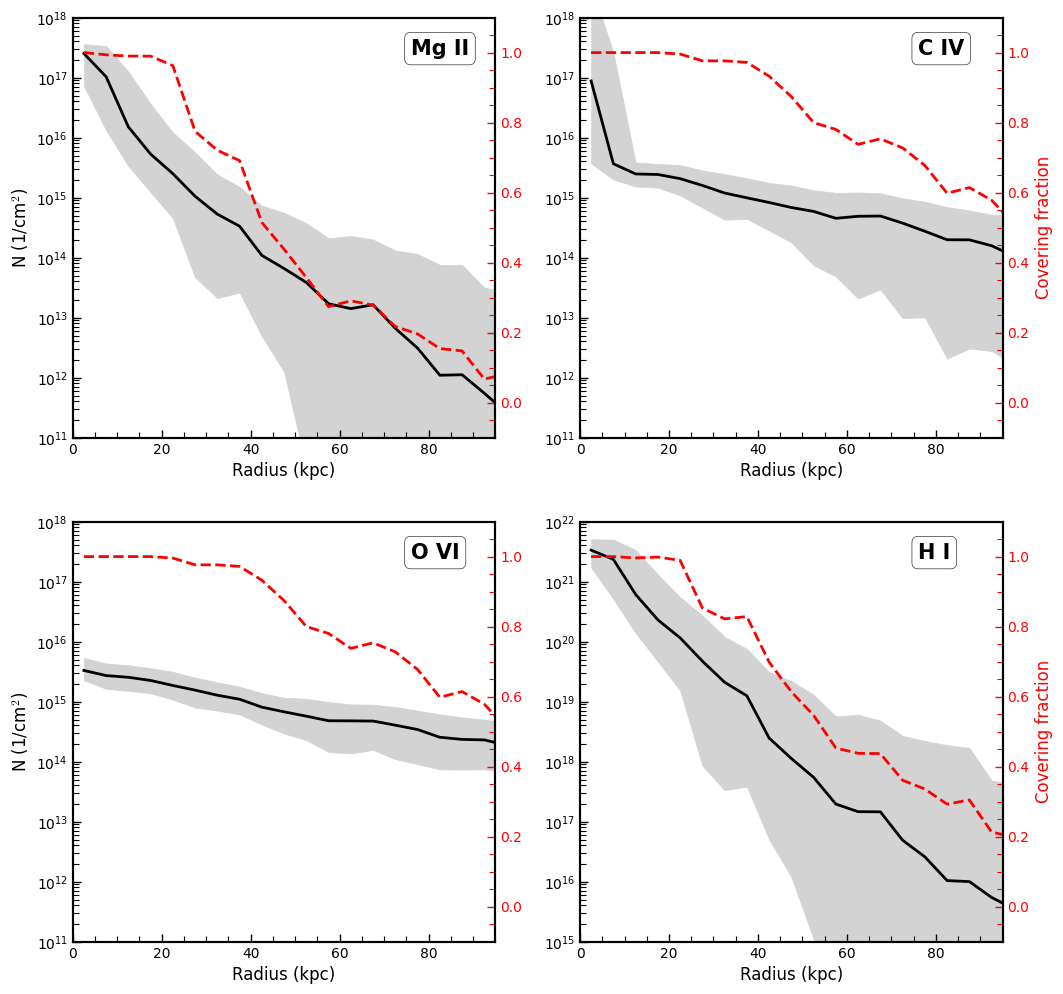

In [377]:
fig, axes = plt.subplots(figsize=(12, 12), nrows=2, ncols=2)

# -------------------- Mg II
# Plot 1 - Column density profile

ax1 = axes[0,0]
ax1.plot(radial_centers, radial_profiles[:, 1, 0], color='black')
ax1.fill_between(radial_centers, radial_profiles[:, 0, 0], radial_profiles[:, 2, 0], color='lightgray')
ax1.set_yscale('log')
ax1.set_ylim(1e11, 1e18)
ax1.set_xlabel('Radius (kpc)')
ax1.set_ylabel(r'N (1/cm$^2$)')

ax1.text(0.8, 0.95, 'Mg II', transform=ax1.transAxes,
         fontsize=15, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

# Plot 2 - Covering fraction
ax1_twin = ax1.twinx()
ax1_twin.plot(radial_centers, covering_fractions[:,0], color='red', linestyle='dashed')
ax1_twin.tick_params(axis='y', colors='red', which='both')           # Set tick color
ax1_twin.set_ylim(-0.1, 1.1)
plt.xlim(0,95)

# -------------------- C IV
# Plot 1 - Column density profile
ax2 = axes[0,1]
ax2.plot(radial_centers, radial_profiles[:, 1, 1], color='black')
ax2.fill_between(radial_centers, radial_profiles[:, 0, 1], radial_profiles[:, 2, 1], color='lightgray')
ax2.set_yscale('log')
ax2.set_ylim(1e11, 1e18)
ax2.set_xlabel('Radius (kpc)')

ax2.text(0.8, 0.95, 'C IV', transform=ax2.transAxes,
         fontsize=15, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

# Plot 2 - Covering fraction
ax2_twin = ax2.twinx()
ax2_twin.plot(radial_centers, covering_fractions[:,1], color='red', linestyle='dashed')
ax2_twin.set_ylabel('Covering fraction', color='red')  # Set y-axis label color
ax2_twin.tick_params(axis='y', colors='red', which='both')           # Set tick color
ax2_twin.set_ylim(-0.1, 1.1)
plt.xlim(0,95)

# -------------------- O VI
# Plot 1 - Column density profile
ax3 = axes[1,0]
ax3.plot(radial_centers, radial_profiles[:, 1, 2], color='black')
ax3.fill_between(radial_centers, radial_profiles[:, 0, 2], radial_profiles[:, 2, 2], color='lightgray')
ax3.set_yscale('log')
ax3.set_ylim(1e11, 1e18)
ax3.set_xlabel('Radius (kpc)')
ax3.set_ylabel(r'N (1/cm$^2$)')

ax3.text(0.8, 0.95, 'O VI', transform=ax3.transAxes,
         fontsize=15, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))

# Plot 2 - Covering fraction
ax3_twin = ax3.twinx()
ax3_twin.plot(radial_centers, covering_fractions[:,1], color='red', linestyle='dashed')
ax3_twin.tick_params(axis='y', colors='red', which='both')           # Set tick color
ax3_twin.set_ylim(-0.1, 1.1)
plt.xlim(0,95)

# --------------------  HI
# Plot 1 - Column density profile
ax4 = axes[1,1]
ax4.plot(radial_centers, radial_profiles[:, 1, 3], color='black')
ax4.fill_between(radial_centers, radial_profiles[:, 0, 3], radial_profiles[:, 2, 3], color='lightgray')
ax4.set_yscale('log')
ax4.set_ylim(1e15, 1e22)
ax4.set_xlabel('Radius (kpc)')

ax4.text(0.8, 0.95, 'H I', transform=ax4.transAxes,
         fontsize=15, fontweight='bold', va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.8))


# Plot 2 - Covering fraction
ax4_twin = ax4.twinx()
ax4_twin.plot(radial_centers, covering_fractions[:,3], color='red', linestyle='dashed')
ax4_twin.set_ylabel('Covering fraction', color='red')  # Set y-axis label color
ax4_twin.tick_params(axis='y', colors='red', which='both')           # Set tick color
ax4_twin.set_ylabel('Covering fraction')
ax4_twin.set_ylim(-0.1, 1.1)
plt.xlim(0,95)

plt.show()

# Useful references and links

- [TNG project website](https://www.tng-project.org)
- [CGM lectures summary including basic tutorials on TNG simulations](https://arxiv.org/pdf/2411.07988)
- [All TNG-related papers](https://www.tng-project.org/results/)
- [TNG Web-browsable Data access API](https://www.tng-project.org/api/)
- [TNG tutorials on how to access the data](https://www.tng-project.org/data/docs/api/)